# Book Recommendation System

Popularity-based and collaborative-filtering recommendations on the Book-Crossing dataset.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="tab10")
pd.set_option("display.max_columns", None)

## Load data

We load the three CSV files using `;` as the separator and `latin-1` encoding because this dataset contains older text encodings.

In [2]:
books = pd.read_csv(
    Path("../data/BX_Books.csv"),
    sep=";",
    encoding="latin-1",
    on_bad_lines="skip",
    low_memory=False
)

users = pd.read_csv(
    Path("../data/BX-Users.csv"),
    sep=";",
    encoding="latin-1",
    on_bad_lines="skip"
)

ratings = pd.read_csv(
    Path("../data/BX-Book-Ratings.csv"),
    sep=";",
    encoding="latin-1",
    on_bad_lines="skip"
)

In [3]:
print("Books shape:", books.shape)
print("Users shape:", users.shape)
print("Ratings shape:", ratings.shape)

Books shape: (271379, 8)
Users shape: (278858, 3)
Ratings shape: (1149780, 3)


In [4]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton & Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [5]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [6]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


## Rename columns

The original column names contain hyphens and mixed capitalization. Renaming them makes the code easier to read and avoids repeated bracket-heavy syntax.

In [7]:
books.columns = [
    "ISBN", "bookTitle", "bookAuthor", "yearOfPublication",
    "publisher", "imageUrlS", "imageUrlM", "imageUrlL"
]
ratings.columns = ["userID", "ISBN", "bookRating"]
users.columns = ["userID", "location", "age"]

In [8]:
print("Books missing values:")
print(books.isna().sum())

print("Users missing values:")
print(users.isna().sum())

print("Ratings missing values:")
print(ratings.isna().sum())

Books missing values:
ISBN                 0
bookTitle            0
bookAuthor           2
yearOfPublication    0
publisher            2
imageUrlS            0
imageUrlM            0
imageUrlL            0
dtype: int64
Users missing values:
userID           0
location         0
age         110762
dtype: int64
Ratings missing values:
userID        0
ISBN          0
bookRating    0
dtype: int64


## Clean data

Important cleaning decisions:

- Convert `age`, `yearOfPublication`, and `bookRating` to numeric values.
- Keep realistic ages only: `1` to `100`.
- Keep realistic publication years only: `1800` to `2026`.
- Drop books missing key metadata such as title, author, or publisher.
- Use only explicit ratings: `bookRating > 0`.

This prevents strange values like age `244`, publication year `0`, or implicit `0` ratings from damaging the recommender.

In [9]:
users_clean = users.copy()
books_clean = books.copy()
ratings_clean = ratings.copy()

users_clean["age"] = pd.to_numeric(users_clean["age"], errors="coerce")
books_clean["yearOfPublication"] = pd.to_numeric(
    books_clean["yearOfPublication"],
    errors="coerce"
)
ratings_clean["bookRating"] = pd.to_numeric(
    ratings_clean["bookRating"],
    errors="coerce"
)

users_clean = users_clean[
    users_clean["age"].between(1, 100) | users_clean["age"].isna()
].copy()

books_clean = books_clean[
    books_clean["yearOfPublication"].between(1800, 2026)
].copy()

books_clean = books_clean.dropna(
    subset=["ISBN", "bookTitle", "bookAuthor", "publisher"]
).copy()

ratings_clean = ratings_clean[
    ratings_clean["bookRating"].between(1, 10)
].copy()

In [10]:
print("Clean users:", users_clean.shape)
print("Clean books:", books_clean.shape)
print("Explicit ratings:", ratings_clean.shape)

Clean users: (278076, 3)
Clean books: (266743, 8)
Explicit ratings: (433671, 3)


## Merge data

We merge ratings with users and books to create one analysis table. Inner joins keep only ratings that have matching user and book information.

In [11]:
df = (
    ratings_clean
    .merge(users_clean, on="userID", how="inner")
    .merge(books_clean, on="ISBN", how="inner")
)

df.head()

,userID,ISBN,bookRating,location,age,bookTitle,bookAuthor,yearOfPublication,publisher,imageUrlS,imageUrlM,imageUrlL
0,276726,0155061224,5,"seattle, washington, usa",NaN,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
1,276729,052165615X,3,"rijeka, n/a, croatia",16.0,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
2,276729,0521795028,6,"rijeka, n/a, croatia",16.0,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
3,276744,038550120X,7,"torrance, california, usa",NaN,A Painted House,JOHN GRISHAM,2001,Doubleday,http://images.amazon.com/images/P/038550120X.0...,http://images.amazon.com/images/P/038550120X.0...,http://images.amazon.com/images/P/038550120X.0...
4,276747,0060517794,9,"iowa city, iowa, usa",25.0,Little Altars Everywhere,Rebecca Wells,2003,HarperTorch,http://images.amazon.com/images/P/0060517794.0...,http://images.amazon.com/images/P/0060517794.0...,http://images.amazon.com/images/P/0060517794.0...


In [12]:
print("Merged data shape:", df.shape)
print("Unique users:", df["userID"].nunique())
print("Unique books:", df["bookTitle"].nunique())

Merged data shape: (377100, 12)
Unique users: 66916
Unique books: 133168


## Exploratory data analysis

These plots help us understand user behavior, rating patterns, book popularity, author/publisher frequency, and country-level activity.

### Age

This shows the age spread of users after removing invalid ages. Missing ages are ignored by the plot.

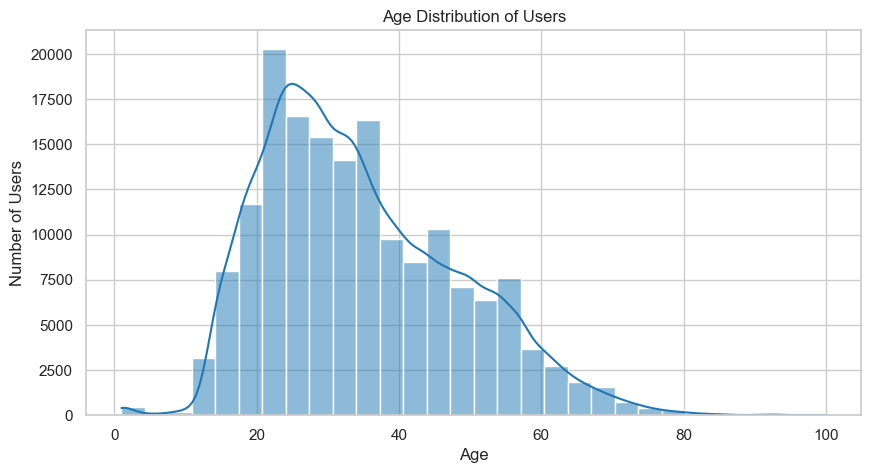

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=users_clean,
    x="age",
    bins=30,
    kde=True,
    ax=ax
)

ax.set_title("Age Distribution of Users")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Users")

plt.show()

### Ratings

Only explicit ratings from `1` to `10` are shown here. This is the rating data used by the recommender.

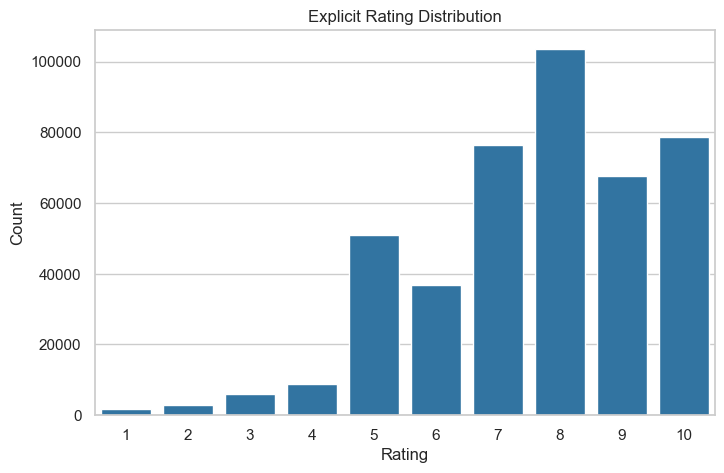

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=ratings_clean,
    x="bookRating",
    ax=ax
)

ax.set_title("Explicit Rating Distribution")
ax.set_xlabel("Rating")
ax.set_ylabel("Count")

plt.show()

### Publication year

This shows how many books were published in each period after cleaning invalid years.

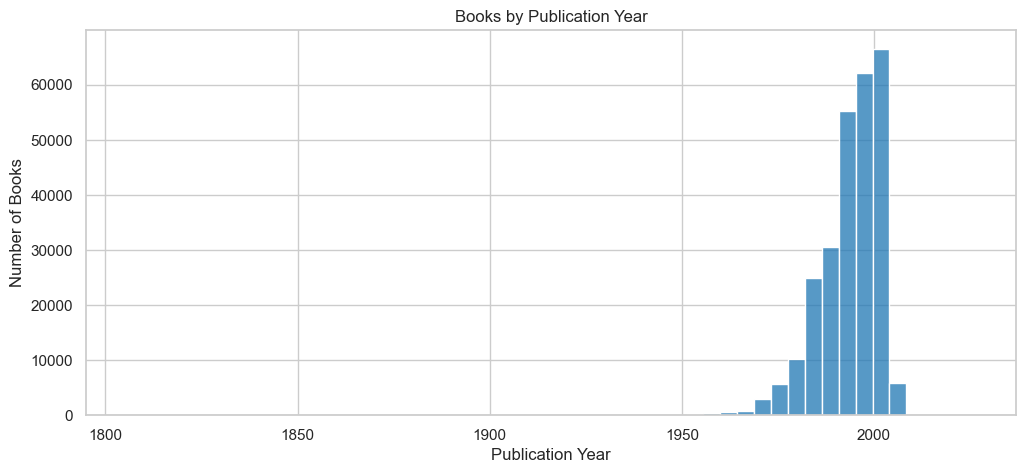

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(
    data=books_clean,
    x="yearOfPublication",
    bins=50,
    ax=ax
)

ax.set_title("Books by Publication Year")
ax.set_xlabel("Publication Year")
ax.set_ylabel("Number of Books")

plt.show()

### Most rated books

These books received the largest number of ratings, so they are the most popular by interaction volume.

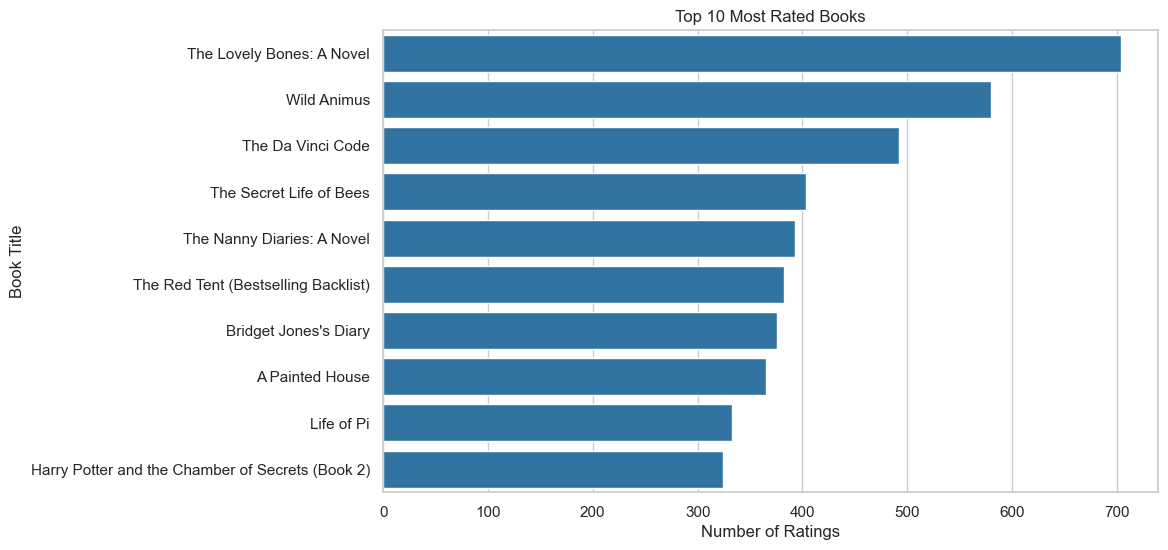

In [16]:
top_rated_books = (
    df.groupby("bookTitle")["bookRating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=top_rated_books.values,
    y=top_rated_books.index,
    ax=ax
)

ax.set_title("Top 10 Most Rated Books")
ax.set_xlabel("Number of Ratings")
ax.set_ylabel("Book Title")

plt.show()

### Authors and publishers

These plots show which authors and publishers appear most often in the book metadata.

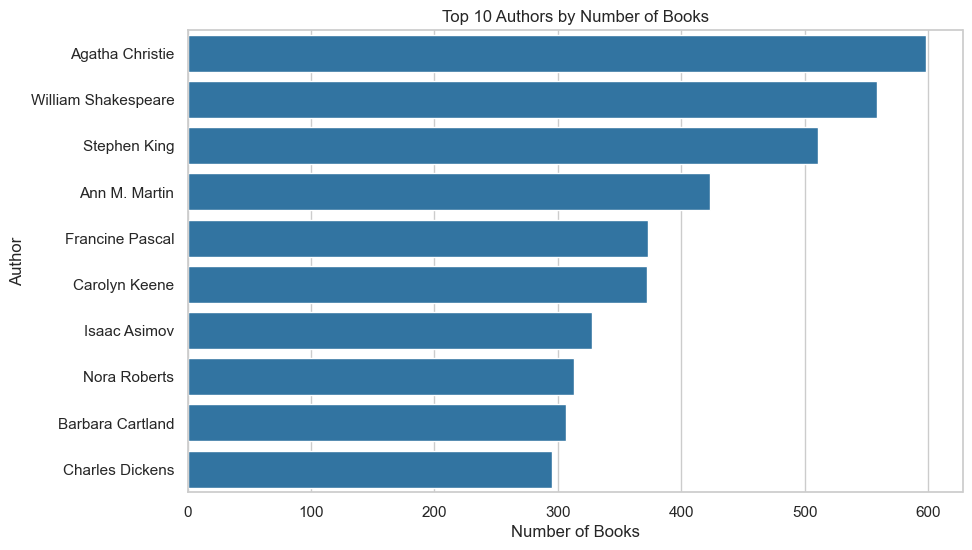

In [17]:
top_authors_books = books_clean["bookAuthor"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=top_authors_books.values,
    y=top_authors_books.index,
    ax=ax
)

ax.set_title("Top 10 Authors by Number of Books")
ax.set_xlabel("Number of Books")
ax.set_ylabel("Author")

plt.show()

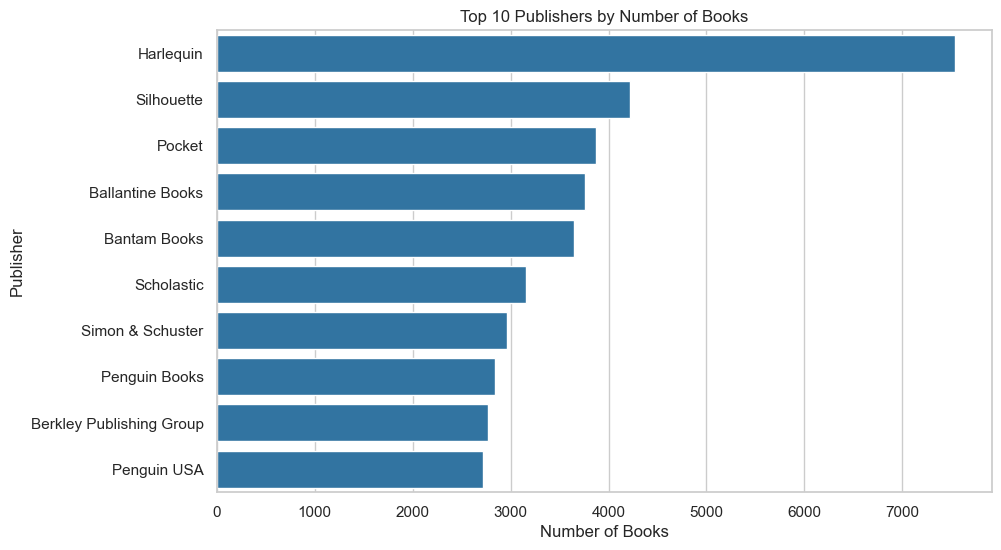

In [18]:
top_publishers = books_clean["publisher"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=top_publishers.values,
    y=top_publishers.index,
    ax=ax
)

ax.set_title("Top 10 Publishers by Number of Books")
ax.set_xlabel("Number of Books")
ax.set_ylabel("Publisher")

plt.show()

### Active users

These users gave the largest number of explicit ratings.

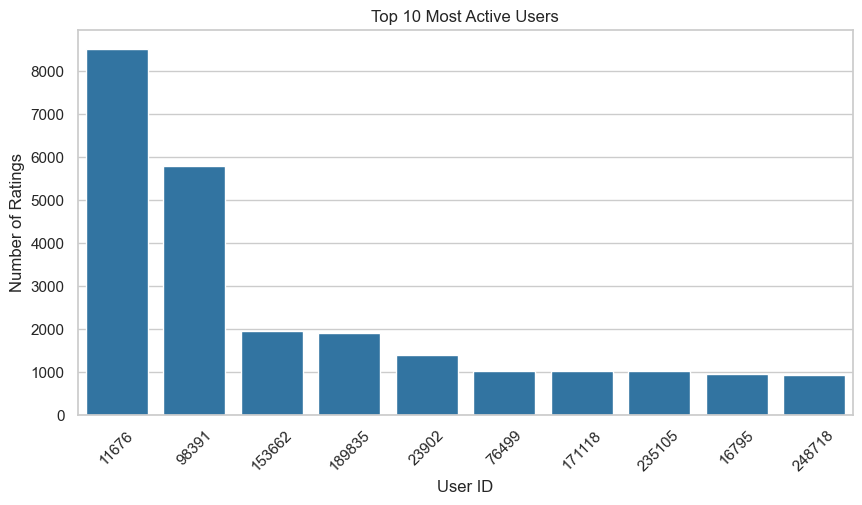

In [19]:
top_users = ratings_clean["userID"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x=top_users.index.astype(str),
    y=top_users.values,
    ax=ax
)

ax.set_title("Top 10 Most Active Users")
ax.set_xlabel("User ID")
ax.set_ylabel("Number of Ratings")
ax.tick_params(axis="x", rotation=45)

plt.show()

### Age groups and ratings

Age groups make rating behavior easier to compare than individual ages.

In [20]:
age_bins = [0, 18, 25, 35, 50, 100]
age_labels = ["0-18", "19-25", "26-35", "36-50", "50+"]

users_clean["ageGroup"] = pd.cut(
    users_clean["age"],
    bins=age_bins,
    labels=age_labels
)

df["ageGroup"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)

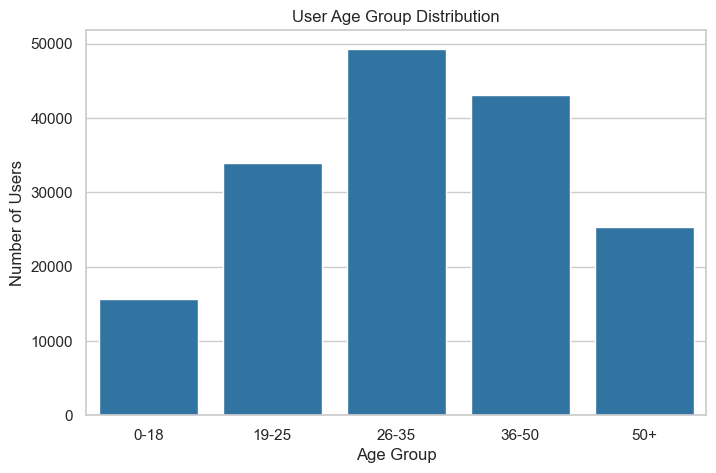

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=users_clean,
    x="ageGroup",
    ax=ax
)

ax.set_title("User Age Group Distribution")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Users")

plt.show()

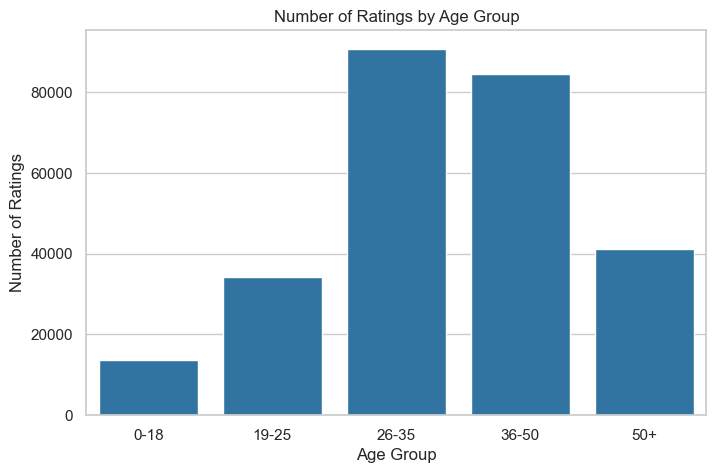

In [22]:
ratings_by_age_group = df.groupby("ageGroup", observed=True)["bookRating"].count()

fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=ratings_by_age_group.index,
    y=ratings_by_age_group.values,
    ax=ax
)

ax.set_title("Number of Ratings by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Ratings")

plt.show()

### Age group vs rating

This heatmap shows how many ratings each age group gave for each rating value.

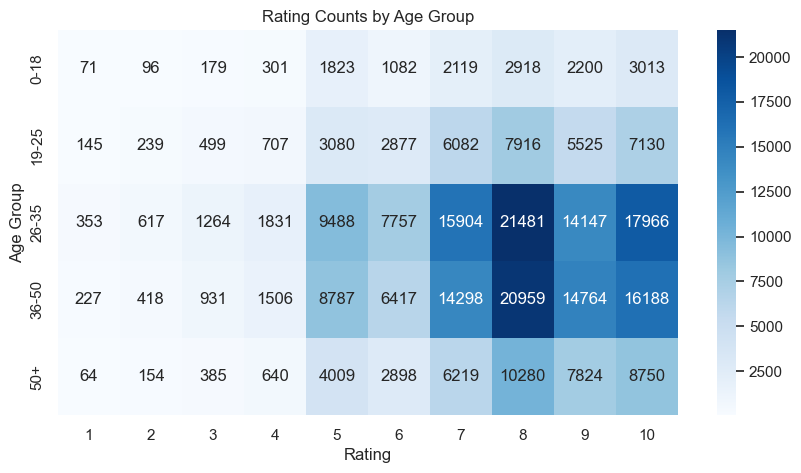

In [23]:
age_rating_heatmap = pd.crosstab(
    df["ageGroup"],
    df["bookRating"]
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    age_rating_heatmap,
    cmap="Blues",
    annot=True,
    fmt="d",
    ax=ax
)

ax.set_title("Rating Counts by Age Group")
ax.set_xlabel("Rating")
ax.set_ylabel("Age Group")

plt.show()

### Country analysis

The country is extracted from the last part of the `location` field. Because locations are user-entered text, some country names may still be messy.

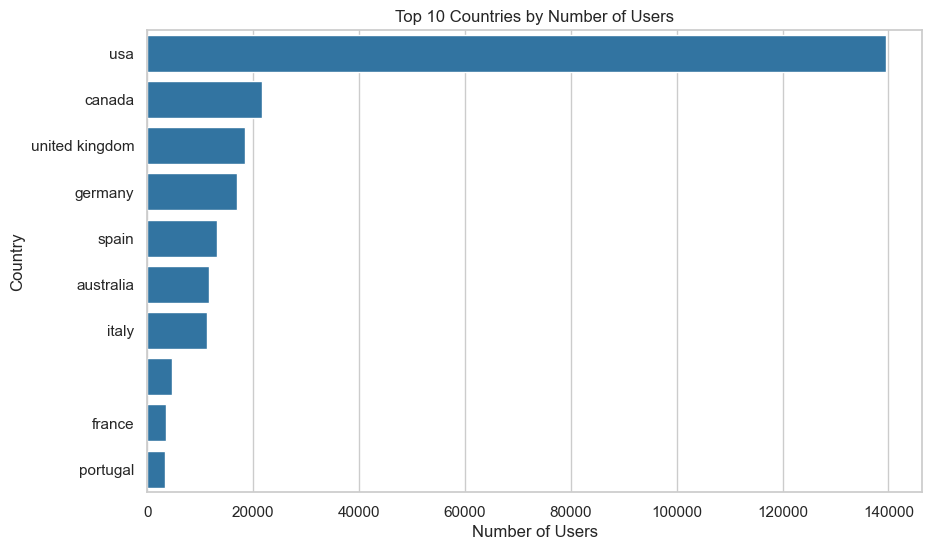

In [24]:
users_clean["country"] = users_clean["location"].str.split(",").str[-1].str.strip().str.lower()
df["country"] = df["location"].str.split(",").str[-1].str.strip().str.lower()

top_countries_users = users_clean["country"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=top_countries_users.values,
    y=top_countries_users.index,
    ax=ax
)

ax.set_title("Top 10 Countries by Number of Users")
ax.set_xlabel("Number of Users")
ax.set_ylabel("Country")

plt.show()

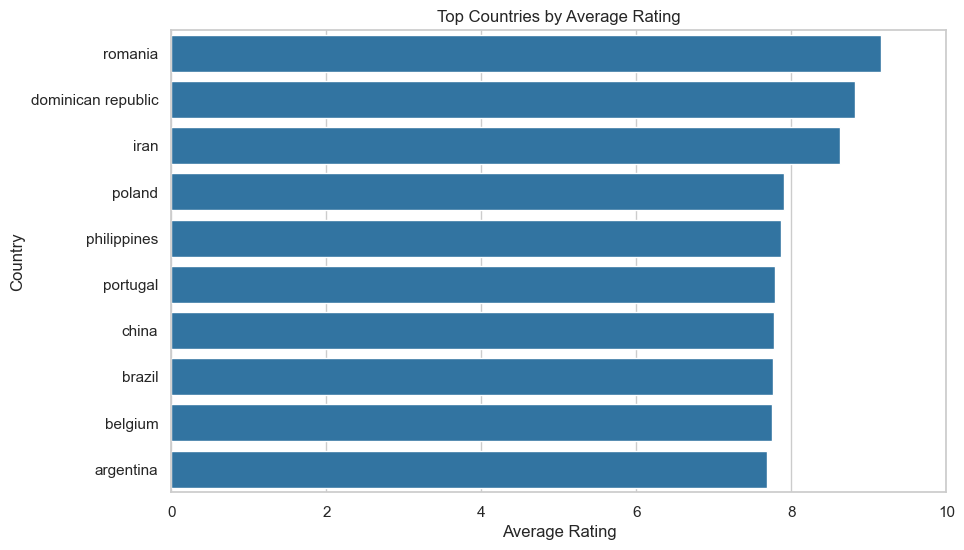

In [25]:
country_stats = (
    df.groupby("country")["bookRating"]
    .agg(["mean", "count"])
    .reset_index()
)

top_country_avg = (
    country_stats[country_stats["count"] >= 100]
    .sort_values("mean", ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=top_country_avg,
    x="mean",
    y="country",
    ax=ax
)

ax.set_title("Top Countries by Average Rating")
ax.set_xlabel("Average Rating")
ax.set_ylabel("Country")
ax.set_xlim(0, 10)

plt.show()

### Correlation

This checks simple numeric relationships between age, rating, and publication year. The correlations may be weak, but the plot is useful for quick inspection.

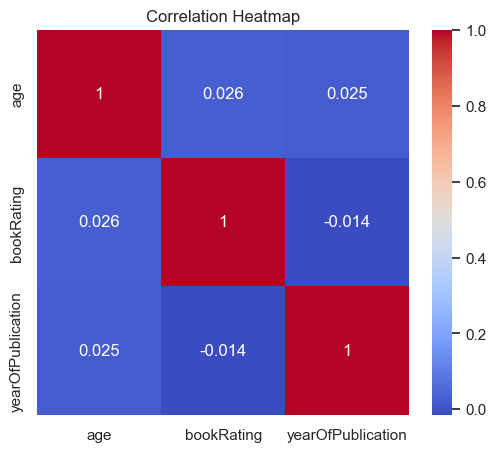

In [26]:
corr_df = df[["age", "bookRating", "yearOfPublication"]].dropna()

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    ax=ax
)

ax.set_title("Correlation Heatmap")

plt.show()

## Filter sparse data

Recommendation models work better when we remove users and books with too little interaction data.

Here we keep:

- Users with at least `50` explicit ratings.
- Books with at least `20` explicit ratings.

This gives the similarity model enough evidence to compare books.

In [27]:
min_user_ratings = 50
min_book_ratings = 20

user_rating_counts = df["userID"].value_counts()
active_users = user_rating_counts[user_rating_counts >= min_user_ratings].index

df_filtered = df[df["userID"].isin(active_users)].copy()

book_rating_counts = df_filtered["bookTitle"].value_counts()
popular_book_titles = book_rating_counts[book_rating_counts >= min_book_ratings].index

df_filtered = df_filtered[df_filtered["bookTitle"].isin(popular_book_titles)].copy()

print("Original ratings:", ratings.shape[0])
print("Explicit ratings:", ratings_clean.shape[0])
print("Merged explicit ratings:", df.shape[0])
print("Final filtered ratings:", df_filtered.shape[0])
print("Unique users:", df_filtered["userID"].nunique())
print("Unique books:", df_filtered["bookTitle"].nunique())

Original ratings: 1149780
Explicit ratings: 433671
Merged explicit ratings: 377100
Final filtered ratings: 16255
Unique users: 1108
Unique books: 471


## Popularity recommender

This is the baseline model. It recommends books that have high average ratings and enough rating volume.

A book with one `10/10` rating should not beat a book with thousands of strong ratings, so the popularity score combines average rating and number of ratings.

In [28]:
book_stats = (
    df_filtered
    .groupby("bookTitle")["bookRating"]
    .agg(["mean", "count"])
    .reset_index()
)

book_stats.columns = ["bookTitle", "averageRating", "numberOfRatings"]
book_stats["popularityScore"] = book_stats["averageRating"] * book_stats["numberOfRatings"]

book_stats.sort_values("popularityScore", ascending=False).head(10)

,bookTitle,averageRating,numberOfRatings,popularityScore
372,The Lovely Bones: A Novel,8.229008,131,1078.0
153,Harry Potter and the Chamber of Secrets (Book 2),8.850000,120,1062.0
156,Harry Potter and the Prisoner of Azkaban (Book 3),8.924528,106,946.0
62,Bridget Jones's Diary,7.586207,116,880.0
324,The Da Vinci Code,8.574257,101,866.0
154,Harry Potter and the Goblet of Fire (Book 4),9.170213,94,862.0
404,The Secret Life of Bees,8.663265,98,849.0
435,To Kill a Mockingbird,8.966667,90,807.0
158,Harry Potter and the Sorcerer's Stone (Harry P...,8.954545,88,788.0
155,Harry Potter and the Order of the Phoenix (Boo...,8.936709,79,706.0


In [29]:
def recommend_popular_books(n=10):
    return (
        book_stats
        .sort_values("popularityScore", ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

recommend_popular_books(10)

,bookTitle,averageRating,numberOfRatings,popularityScore
0,The Lovely Bones: A Novel,8.229008,131,1078.0
1,Harry Potter and the Chamber of Secrets (Book 2),8.850000,120,1062.0
2,Harry Potter and the Prisoner of Azkaban (Book 3),8.924528,106,946.0
3,Bridget Jones's Diary,7.586207,116,880.0
4,The Da Vinci Code,8.574257,101,866.0
5,Harry Potter and the Goblet of Fire (Book 4),9.170213,94,862.0
6,The Secret Life of Bees,8.663265,98,849.0
7,To Kill a Mockingbird,8.966667,90,807.0
8,Harry Potter and the Sorcerer's Stone (Harry P...,8.954545,88,788.0
9,Harry Potter and the Order of the Phoenix (Boo...,8.936709,79,706.0


## User-book matrix

The user-book matrix is the foundation for collaborative filtering.

- Rows are users.
- Columns are book titles.
- Values are ratings.
- Missing values mean the user did not rate that book.

In [30]:
user_book_matrix = df_filtered.pivot_table(
    index="userID",
    columns="bookTitle",
    values="bookRating"
)

print("User-book matrix shape:", user_book_matrix.shape)
user_book_matrix.head()

User-book matrix shape: (1108, 471)


bookTitle,1984,1st to Die: A Novel,2nd Chance,A Bend in the Road,A Case of Need,"A Child Called \It\"": One Child's Courage to Survive""",A Heartbreaking Work of Staggering Genius,A Is for Alibi (Kinsey Millhone Mysteries (Paperback)),A Kiss of Shadows (Meredith Gentry Novels (Paperback)),A Map of the World,A Painted House,A Prayer for Owen Meany,A Separate Peace,A Time to Kill,A Walk in the Woods: Rediscovering America on the Appalachian Trail (Official Guides to the Appalachian Trail),A Walk to Remember,A Wrinkle In Time,A Wrinkle in Time,A Year in Provence,ANGELA'S ASHES,About a Boy,Airframe,All Around the Town,All I Really Need to Know,All That Remains (Kay Scarpetta Mysteries (Paperback)),Along Came a Spider (Alex Cross Novels),American Gods,American Psycho (Vintage Contemporaries),Angela's Ashes (MMP) : A Memoir,Angela's Ashes: A Memoir,Angels & Demons,"Angus, Thongs and Full-Frontal Snogging: Confessions of Georgia Nicolson",Animal Farm,Anne Frank: The Diary of a Young Girl,Anne of Avonlea (Anne of Green Gables Novels (Paperback)),Anne of Green Gables (Anne of Green Gables Novels (Paperback)),"Artemis Fowl (Artemis Fowl, Book 1)",Ashes to Ashes,At Home in Mitford (The Mitford Years),Atlas Shrugged,B Is for Burglar (Kinsey Millhone Mysteries (Paperback)),Back Roads,Back When We Were Grownups: A Novel,Bag of Bones,Balzac and the Little Chinese Seamstress : A Novel,Bastard Out of Carolina,Bel Canto: A Novel,Beloved,Beloved (Plume Contemporary Fiction),Big Cherry Holler: A Big Stone Gap Novel (Ballantine Reader's Circle),Big Stone Gap: A Novel (Ballantine Reader's Circle),Big Trouble,Black House,Black Notice,Black and Blue,Bleachers,Bloody Bones (Anita Blake Vampire Hunter (Paperback)),Blue Diary,Body of Evidence (Kay Scarpetta Mysteries (Paperback)),Brave New World,Breathing Lessons,Bridget Jones : The Edge of Reason,Bridget Jones's Diary,Bridget Jones: The Edge of Reason,By the Light of the Moon,C Is for Corpse (Kinsey Millhone Mysteries (Paperback)),Carolina Moon,Carrie,Cat & Mouse (Alex Cross Novels),Cause of Death,Charlie and the Chocolate Factory,Charlotte's Web (Trophy Newbery),Chicken Soup for the Soul (Chicken Soup for the Soul),Chicken Soup for the Woman's Soul (Chicken Soup for the Soul Series (Paper)),Chocolat,Chosen Prey,Christine,Circle of Friends,Circus of the Damned (Anita Blake Vampire Hunter (Paperback)),Cold Mountain,Cold Mountain : A Novel,Cold Sassy Tree,Confessions of a Shopaholic (Summer Display Opportunity),Confessions of an Ugly Stepsister : A Novel,Congo,Coraline,Cradle and All,Cruel & Unusual (Kay Scarpetta Mysteries (Paperback)),Cujo,D Is for Deadbeat (Kinsey Millhone Mysteries (Paperback)),Daddy's Little Girl,Dance upon the Air (Three Sisters Island Trilogy),Dark Paradise,Death du Jour,Deja Dead,Desperation,Different Seasons,Digital Fortress : A Thriller,Disclosure,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Dolores Claiborne,Don't Sweat the Small Stuff and It's All Small Stuff : Simple Ways to Keep the Little Things from Taking Over Your Life (Don't Sweat the Small Stuff Series),Doomsday Book,Dragonfly in Amber,Dreamcatcher,Drums of Autumn,"Dude, Where's My Country?",Dune (Remembering Tomorrow),E Is for Evidence: A Kinsey Millhone Mystery (Kinsey Millhone Mysteries (Paperback)),Easy Prey,"Eats, Shoots & Leaves: The Zero Tolerance Approach to Punctuation",Einstein's Dreams,Ellen Foster,Empire Falls,Ender's Game (Ender Wiggins Saga (Paperback)),Everything's Eventual : 14 Dark Tales,Eyes of Prey,F Is for Fugitive (Kinsey Millhone Mysteries (Paperback)),Face the Fire (Three Sisters Island Trilogy),Fahrenheit 451,Faking It,Fall On Your Knees (Oprah #45),False Memory,Fast Food Nation: The Dark Side of the All-American Meal,Fast Women,Fear Nothing,Final Target,Fingersmith,Firestarter,Five Quarters of the Orange,Flesh and Blood,"Fluke : Or, I Know Why the Winged Whale Sings",Four Blind Mice,Four Past Midnight,Four To Score (A Stephanie Plum Novel),Fried Green Tomatoes at the Whistle Stop Cafe,From 

## Collaborative filtering

We fill missing ratings with `0` so cosine similarity can compare books. Then we transpose the matrix so each row represents a book and each column represents a user.

Cosine similarity measures whether two books were rated similarly by the same users.

In [31]:
from sklearn.metrics.pairwise import cosine_similarity

user_book_matrix_filled = user_book_matrix.fillna(0)
book_similarity = cosine_similarity(user_book_matrix_filled.T)

book_similarity_df = pd.DataFrame(
    book_similarity,
    index=user_book_matrix_filled.columns,
    columns=user_book_matrix_filled.columns
)

book_similarity_df.head()

bookTitle,1984,1st to Die: A Novel,2nd Chance,A Bend in the Road,A Case of Need,"A Child Called \It\"": One Child's Courage to Survive""",A Heartbreaking Work of Staggering Genius,A Is for Alibi (Kinsey Millhone Mysteries (Paperback)),A Kiss of Shadows (Meredith Gentry Novels (Paperback)),A Map of the World,A Painted House,A Prayer for Owen Meany,A Separate Peace,A Time to Kill,A Walk in the Woods: Rediscovering America on the Appalachian Trail (Official Guides to the Appalachian Trail),A Walk to Remember,A Wrinkle In Time,A Wrinkle in Time,A Year in Provence,ANGELA'S ASHES,About a Boy,Airframe,All Around the Town,All I Really Need to Know,All That Remains (Kay Scarpetta Mysteries (Paperback)),Along Came a Spider (Alex Cross Novels),American Gods,American Psycho (Vintage Contemporaries),Angela's Ashes (MMP) : A Memoir,Angela's Ashes: A Memoir,Angels & Demons,"Angus, Thongs and Full-Frontal Snogging: Confessions of Georgia Nicolson",Animal Farm,Anne Frank: The Diary of a Young Girl,Anne of Avonlea (Anne of Green Gables Novels (Paperback)),Anne of Green Gables (Anne of Green Gables Novels (Paperback)),"Artemis Fowl (Artemis Fowl, Book 1)",Ashes to Ashes,At Home in Mitford (The Mitford Years),Atlas Shrugged,B Is for Burglar (Kinsey Millhone Mysteries (Paperback)),Back Roads,Back When We Were Grownups: A Novel,Bag of Bones,Balzac and the Little Chinese Seamstress : A Novel,Bastard Out of Carolina,Bel Canto: A Novel,Beloved,Beloved (Plume Contemporary Fiction),Big Cherry Holler: A Big Stone Gap Novel (Ballantine Reader's Circle),Big Stone Gap: A Novel (Ballantine Reader's Circle),Big Trouble,Black House,Black Notice,Black and Blue,Bleachers,Bloody Bones (Anita Blake Vampire Hunter (Paperback)),Blue Diary,Body of Evidence (Kay Scarpetta Mysteries (Paperback)),Brave New World,Breathing Lessons,Bridget Jones : The Edge of Reason,Bridget Jones's Diary,Bridget Jones: The Edge of Reason,By the Light of the Moon,C Is for Corpse (Kinsey Millhone Mysteries (Paperback)),Carolina Moon,Carrie,Cat & Mouse (Alex Cross Novels),Cause of Death,Charlie and the Chocolate Factory,Charlotte's Web (Trophy Newbery),Chicken Soup for the Soul (Chicken Soup for the Soul),Chicken Soup for the Woman's Soul (Chicken Soup for the Soul Series (Paper)),Chocolat,Chosen Prey,Christine,Circle of Friends,Circus of the Damned (Anita Blake Vampire Hunter (Paperback)),Cold Mountain,Cold Mountain : A Novel,Cold Sassy Tree,Confessions of a Shopaholic (Summer Display Opportunity),Confessions of an Ugly Stepsister : A Novel,Congo,Coraline,Cradle and All,Cruel & Unusual (Kay Scarpetta Mysteries (Paperback)),Cujo,D Is for Deadbeat (Kinsey Millhone Mysteries (Paperback)),Daddy's Little Girl,Dance upon the Air (Three Sisters Island Trilogy),Dark Paradise,Death du Jour,Deja Dead,Desperation,Different Seasons,Digital Fortress : A Thriller,Disclosure,Divine Secrets of the Ya-Ya Sisterhood: A Novel,Dolores Claiborne,Don't Sweat the Small Stuff and It's All Small Stuff : Simple Ways to Keep the Little Things from Taking Over Your Life (Don't Sweat the Small Stuff Series),Doomsday Book,Dragonfly in Amber,Dreamcatcher,Drums of Autumn,"Dude, Where's My Country?",Dune (Remembering Tomorrow),E Is for Evidence: A Kinsey Millhone Mystery (Kinsey Millhone Mysteries (Paperback)),Easy Prey,"Eats, Shoots & Leaves: The Zero Tolerance Approach to Punctuation",Einstein's Dreams,Ellen Foster,Empire Falls,Ender's Game (Ender Wiggins Saga (Paperback)),Everything's Eventual : 14 Dark Tales,Eyes of Prey,F Is for Fugitive (Kinsey Millhone Mysteries (Paperback)),Face the Fire (Three Sisters Island Trilogy),Fahrenheit 451,Faking It,Fall On Your Knees (Oprah #45),False Memory,Fast Food Nation: The Dark Side of the All-American Meal,Fast Women,Fear Nothing,Final Target,Fingersmith,Firestarter,Five Quarters of the Orange,Flesh and Blood,"Fluke : Or, I Know Why the Winged Whale Sings",Four Blind Mice,Four Past Midnight,Four To Score (A Stephanie Plum Novel),Fried Green Tomatoes at the Whistle Stop Cafe,From 

## Recommendation functions

`search_books()` helps find the exact book title in the filtered dataset.

`recommend_similar_books()` returns books with the most similar rating patterns.

In [32]:
book_info = (
    df_filtered
    .groupby("bookTitle")
    .agg(
        bookAuthor=("bookAuthor", "first"),
        publisher=("publisher", "first"),
        yearOfPublication=("yearOfPublication", "first"),
        averageRating=("bookRating", "mean"),
        numberOfRatings=("bookRating", "count"),
        imageUrlM=("imageUrlM", "first")
    )
    .reset_index()
)


def search_books(keyword, n=20):
    keyword = keyword.lower()
    matches = [
        title for title in book_similarity_df.index
        if keyword in title.lower()
    ]
    return matches[:n]


def recommend_similar_books(book_title, n=10):
    if book_title not in book_similarity_df.index:
        return f"Book '{book_title}' not found. Use search_books() to find the exact title."

    similar_books = (
        book_similarity_df[book_title]
        .sort_values(ascending=False)
        .drop(book_title)
        .head(n)
        .reset_index()
    )
    similar_books.columns = ["bookTitle", "similarityScore"]

    recommendations = similar_books.merge(
        book_info,
        on="bookTitle",
        how="left"
    )

    return recommendations

## Test the recommender

Some titles may not exist after filtering, so use `search_books()` first to find the exact title.

In [33]:
search_books("Lovely Bones")

['The Lovely Bones: A Novel']

In [34]:
recommend_similar_books("The Lovely Bones: A Novel", n=10)

,bookTitle,similarityScore,bookAuthor,publisher,yearOfPublication,averageRating,numberOfRatings,imageUrlM
0,Nights in Rodanthe,0.245889,Nicholas Sparks,Warner Books,2002,8.050000,20,http://images.amazon.com/images/P/0446531332.0...
1,The Lake House,0.228537,James Patterson,"Little, Brown",2003,7.095238,21,http://images.amazon.com/images/P/0316603287.0...
2,Where the Heart Is (Oprah's Book Club (Paperba...,0.228421,Billie Letts,Warner Books,1998,8.402985,67,http://images.amazon.com/images/P/0446672211.0...
3,Good in Bed,0.220539,Jennifer Weiner,Washington Square Press,2002,8.101449,69,http://images.amazon.com/images/P/0743418174.0...
4,Snow Falling on Cedars,0.216695,David Guterson,Harcourt,1994,7.952381,63,http://images.amazon.com/images/P/0151001006.0...
5,The Da Vinci Code,0.214087,Dan Brown,Doubleday,2003,8.574257,101,http://images.amazon.com/images/P/0385504209.0...
6,Life of Pi,0.203248,Yann Martel,Harcourt,2002,8.324675,77,http://images.amazon.com/images/P/0151008116.0...
7,The Nanny Diaries: A Novel,0.202444,Emma McLaughlin,St. Martin's Griffin,2003,7.552632,76,http://images.amazon.com/images/P/0312291639.0...
8,Empire Falls,0.197272,Richard Russo,Vintage Books USA,2002,7.755556,45,http://images.amazon.com/images/P/0375726403.0...
9,While I Was Gone,0.196553,Sue Miller,Ballantine Books,1999,7.243243,37,http://images.amazon.com/images/P/0345443284.0...


In [35]:
search_books("Da Vinci")

['The Da Vinci Code']

In [36]:
search_books("Harry Potter")

['Harry Potter and the Chamber of Secrets (Book 2)',
 'Harry Potter and the Goblet of Fire (Book 4)',
 'Harry Potter and the Order of the Phoenix (Book 5)',
 'Harry Potter and the Prisoner of Azkaban (Book 3)',
 "Harry Potter and the Sorcerer's Stone (Book 1)",
 "Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))"]

## Final notes

The popularity recommender is useful as a simple baseline. The collaborative filtering recommender is more personalized around a selected book because it uses user-rating behavior.

For a production app, the next improvements would be:

- Better country cleaning.
- Better title deduplication.
- More careful treatment of implicit `0` ratings.
- The training script in `scripts/train.py` builds the production artifact used by the app.